# lcbinint / VBM — triple-lens light curve comparison

This notebook compares lcbinint against VBMicrolensing for a triple-lens finite-source
light curve.  The system consists of a star hosting a giant planet (mass ratio $q=10^{-2}$)
and a smaller companion ($q_2=10^{-3}$, collinear configuration $\\alpha_\\mathrm{ang}=0$).
The source trajectory passes near the central caustic.

lcbinint applies point-source and hexadecapole shortcuts for most of the light curve and
falls back to inverse-ray shooting only near the caustic, which is why it is faster than
VBM while staying within the requested tolerance.  Limb darkening ($\\gamma=0.5$) amplifies
the speed gap because VBM must integrate the LD profile for every point.

In [1]:
import cmath
import collections
import math
from dataclasses import dataclass
from pathlib import Path
import statistics
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

# Locate the lcbinint build directory without hard-coding an absolute path.
for _build_dir in ["build_new", "build"]:
    _p = next(
        (root / _build_dir
         for root in (Path.cwd(), *Path.cwd().parents)
         if (root / _build_dir).is_dir()),
        None,
    )
    if _p is not None:
        sys.path.insert(0, str(_p))
        break

import lcbinint

try:
    import VBMicrolensing
    _VBM_AVAILABLE = True
except ImportError:
    VBMicrolensing = None
    _VBM_AVAILABLE = False

print(f"VBMicrolensing available: {_VBM_AVAILABLE}")

VBMicrolensing available: True


In [2]:
@dataclass(frozen=True)
class Case:
    # Triple lens geometry
    s: float = 1.2       # binary separation (Einstein ring units)
    q: float = 1.0e-2    # binary mass ratio  m2/m1
    q2: float = 1.0e-3   # tertiary mass ratio m3/m1
    sep2: float = 0.2    # tertiary separation from binary centre
    ang: float = 0.0     # tertiary angle (rad)  — 0: collinear
    # Source trajectory
    t0: float = 0.0
    tE: float = 1.0
    u0: float = -0.05
    alpha: float = 0.0
    rho: float = 5.0e-3  # source radius in Einstein ring units
    # Time grid
    t_min: float = -0.5
    t_max: float = 0.5
    n_times: int = 200


CASE = Case()
TIMES = np.linspace(CASE.t_min, CASE.t_max, CASE.n_times)

OPTIONS = lcbinint.Options(source_bins=50, max_source_bins=400, reltol=1.0e-3)
LIMB_DARKENING = lcbinint.LimbDarkening.linear(0.5)
TIMING_REPEATS = 7


def _lcbi_params(case: Case) -> dict:
    return {
        "t0": case.t0, "tE": case.tE, "u0": case.u0, "alpha": case.alpha,
        "s": case.s, "q": case.q, "q2": case.q2, "sep2": case.sep2, "ang": case.ang,
        "rho": case.rho,
    }


def _vbm_setup(case: Case) -> tuple:
    """Convert triple lens geometry to VBM TripleLightCurve params and time array."""
    eps2 = case.q / (1 + case.q + case.q2)
    eps3 = case.q2 / (1 + case.q + case.q2)
    eps1 = 1.0 - eps2 - eps3
    eps4 = eps2 + eps3
    z1 = complex(-eps4 * case.s, 0.0)
    z2 = complex(eps1*case.s + eps3/eps4*case.sep2*math.cos(case.ang),
                  eps3/eps4*case.sep2*math.sin(case.ang))
    z3 = complex(eps1*case.s - eps2/eps4*case.sep2*math.cos(case.ang),
                 -eps2/eps4*case.sep2*math.sin(case.ang))
    v12 = z2 - z1
    v13 = z3 - z1
    a12 = math.atan2(v12.imag, v12.real)
    psi = math.atan2(v13.imag, v13.real) - a12
    com12 = (eps1 * z1 + eps2 * z2) / (eps1 + eps2)
    D = com12 * cmath.exp(-1j * case.alpha)
    u0_vbm = -case.u0 + D.imag
    alpha_vbm = case.alpha - a12
    times_vbm = (-(TIMES - case.t0) / case.tE + D.real).tolist()
    params = [
        math.log(abs(v12)), math.log(case.q), u0_vbm, alpha_vbm, math.log(case.rho),
        0.0, 0.0, math.log(abs(v13)), math.log(case.q2), psi,
    ]
    return params, times_vbm

In [3]:
def relative_error(reference, values):
    return np.abs(values - reference) / np.maximum(np.abs(reference), 1.0e-12)


def error_summary(reference, values):
    rel = relative_error(reference, values)
    return {
        "max": float(np.nanmax(rel)),
        "p99": float(np.nanpercentile(rel, 99.0)),
        "median": float(np.nanmedian(rel)),
        "rms": float(np.sqrt(np.nanmean(rel * rel))),
    }


def evaluate_lcbinint(limb_darkening):
    lc = lcbinint.LightCurve(lens="triple_lens", options=OPTIONS, limb_darkening=limb_darkening)
    p = _lcbi_params(CASE)
    lc(TIMES, p)  # warm up
    samples = []
    values = None
    for _ in range(TIMING_REPEATS):
        t0s = time.perf_counter()
        values = np.asarray(lc(TIMES, p))
        samples.append(time.perf_counter() - t0s)
    info = lc.info(TIMES, p)
    return lc, values, statistics.median(samples), info, samples


def evaluate_vbm(limb_darkening_gamma):
    if not _VBM_AVAILABLE:
        return np.full_like(TIMES, np.nan), np.nan, []
    vbm = VBMicrolensing.VBMicrolensing()
    vbm.Tol = 1.0e-3
    vbm.a1 = limb_darkening_gamma
    vbm.a2 = 0.0
    vbm_params, times_vbm = _vbm_setup(CASE)
    vbm.TripleLightCurve(vbm_params, times_vbm)  # warm up
    samples = []
    values = None
    for _ in range(TIMING_REPEATS):
        t0s = time.perf_counter()
        values = np.asarray(vbm.TripleLightCurve(vbm_params, times_vbm)[0])
        samples.append(time.perf_counter() - t0s)
    return values, statistics.median(samples), samples


lightcurve, lc_no_ld, lc_no_ld_time, lc_no_ld_info, lc_no_ld_samples = evaluate_lcbinint(
    lcbinint.LimbDarkening.none()
)
_, lc_ld, lc_ld_time, lc_ld_info, lc_ld_samples = evaluate_lcbinint(LIMB_DARKENING)
vbm_no_ld, vbm_no_ld_time, vbm_no_ld_samples = evaluate_vbm(0.0)
vbm_ld, vbm_ld_time, vbm_ld_samples = evaluate_vbm(0.5)

In [4]:
def ms_per_point(elapsed):
    return 1e3 * elapsed / TIMES.size

def spread(samples):
    vals = [ms_per_point(s) for s in samples]
    return f"median={statistics.median(vals):.4f}  min={min(vals):.4f}  max={max(vals):.4f}"

print(f"=== {TIMING_REPEATS}-repeat median, {TIMES.size} points ===")
print(f"  lcbinint no LD : {ms_per_point(lc_no_ld_time):.4f} ms/point")
print(f"  lcbinint LD    : {ms_per_point(lc_ld_time):.4f} ms/point")
if np.isfinite(vbm_no_ld_time):
    print(f"  VBM      no LD : {ms_per_point(vbm_no_ld_time):.4f} ms/point")
    print(f"  VBM      LD    : {ms_per_point(vbm_ld_time):.4f} ms/point")
    print(f"  speedup  no LD : {vbm_no_ld_time / lc_no_ld_time:.1f}×")
    print(f"  speedup  LD    : {vbm_ld_time / lc_ld_time:.1f}×")
    print()
    print("=== Relative error vs VBM ===")
    for label, ref, vals in [("no LD", vbm_no_ld, lc_no_ld), ("LD", vbm_ld, lc_ld)]:
        st = error_summary(ref, vals)
        print(f"  {label:5s}  max={st['max']:.3e}  p99={st['p99']:.3e}  "
              f"median={st['median']:.3e}  rms={st['rms']:.3e}")
print()
print("=== lcbinint method mix ===")
for label, info in [("no LD", lc_no_ld_info), ("LD", lc_ld_info)]:
    counts = collections.Counter(info.finite_source_method_names)
    print(f"  {label:5s}  {dict(counts)}  converged={sum(info.finite_source_converged)}/{TIMES.size}")

=== 7-repeat median, 200 points ===
  lcbinint no LD : 0.4070 ms/point
  lcbinint LD    : 0.4135 ms/point
  VBM      no LD : 0.7065 ms/point
  VBM      LD    : 2.5043 ms/point
  speedup  no LD : 1.7×
  speedup  LD    : 6.1×

=== Relative error vs VBM ===
  no LD  max=1.128e-03  p99=7.220e-04  median=4.197e-05  rms=1.615e-04
  LD     max=7.341e-04  p99=4.049e-04  median=4.836e-05  rms=1.132e-04

=== lcbinint method mix ===
  no LD  {'point_source': 115, 'hexadecapole': 48, 'inverse_ray_cartesian': 37}  converged=200/200
  LD     {'point_source': 115, 'hexadecapole': 48, 'inverse_ray_cartesian': 37}  converged=200/200


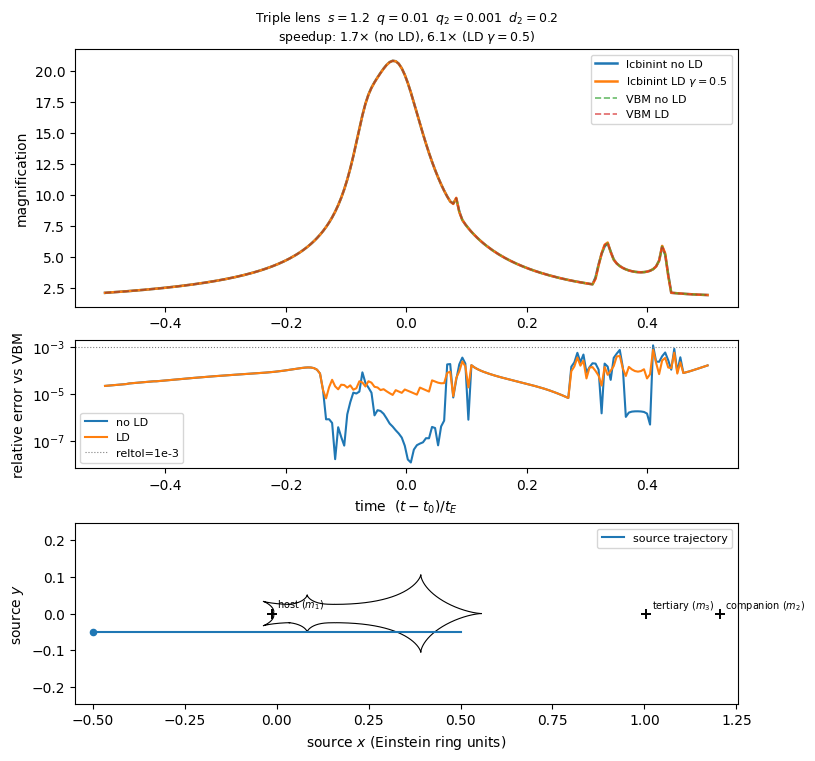

In [5]:
p = _lcbi_params(CASE)
trajectory = lightcurve.source_trajectory(TIMES, p)
caustics   = lightcurve.caustics(p, n_points=1000)

eps2 = CASE.q / (1 + CASE.q + CASE.q2)
eps3 = CASE.q2 / (1 + CASE.q + CASE.q2)
eps1 = 1.0 - eps2 - eps3
eps4 = eps2 + eps3
lens_positions = [
    (-eps4 * CASE.s, 0.0),
    (eps1*CASE.s + eps3/eps4*CASE.sep2*math.cos(CASE.ang),  eps3/eps4*CASE.sep2*math.sin(CASE.ang)),
    (eps1*CASE.s - eps2/eps4*CASE.sep2*math.cos(CASE.ang), -eps2/eps4*CASE.sep2*math.sin(CASE.ang)),
]
lens_labels = [r"host ($m_1$)", r"companion ($m_2$)", r"tertiary ($m_3$)"]

if np.isfinite(vbm_ld_time):
    speedup_str = (
        f"speedup: {vbm_no_ld_time/lc_no_ld_time:.1f}× (no LD), "
        f"{vbm_ld_time/lc_ld_time:.1f}× (LD $\\gamma=0.5$)"
    )
else:
    speedup_str = "VBM not installed"

fig = plt.figure(figsize=(8.0, 7.5), constrained_layout=True)
grid = fig.add_gridspec(3, 1, height_ratios=[2.0, 1.0, 1.4])
ax_mag = fig.add_subplot(grid[0])
ax_res = fig.add_subplot(grid[1], sharex=ax_mag)
ax_geo = fig.add_subplot(grid[2])

ax_mag.set_title(
    f"Triple lens  $s={CASE.s}$  $q={CASE.q}$  $q_2={CASE.q2}$  $d_2={CASE.sep2}$\n{speedup_str}",
    fontsize=9,
)
ax_mag.plot(TIMES, lc_no_ld, label="lcbinint no LD", lw=1.8)
ax_mag.plot(TIMES, lc_ld,    label=r"lcbinint LD $\gamma=0.5$", lw=1.8)
if np.all(np.isfinite(vbm_no_ld)):
    ax_mag.plot(TIMES, vbm_no_ld, "--", label="VBM no LD", lw=1.2, alpha=0.7)
    ax_mag.plot(TIMES, vbm_ld,    "--", label="VBM LD", lw=1.2, alpha=0.7)
ax_mag.set_ylabel("magnification")
ax_mag.legend(loc="best", fontsize=8)

if np.all(np.isfinite(vbm_no_ld)):
    ax_res.semilogy(TIMES, relative_error(vbm_no_ld, lc_no_ld), label="no LD")
    ax_res.semilogy(TIMES, relative_error(vbm_ld, lc_ld),       label="LD")
    ax_res.axhline(1e-3, ls=":", color="gray", lw=0.8, label="reltol=1e-3")
    ax_res.legend(loc="best", fontsize=8)
else:
    ax_res.text(0.5, 0.5, "VBM not installed", ha="center", va="center",
                transform=ax_res.transAxes)
ax_res.set_ylabel("relative error vs VBM")
ax_res.set_xlabel(r"time  $(t - t_0) / t_E$")

for xs, ys in zip(caustics.x, caustics.y):
    ax_geo.plot(xs, ys, color="black", lw=0.8)
ax_geo.plot(trajectory.x, trajectory.y, color="tab:blue", lw=1.5, label="source trajectory")
ax_geo.scatter([trajectory.x[0]], [trajectory.y[0]], s=20, color="tab:blue", zorder=4)
for (lx, ly), label in zip(lens_positions, lens_labels):
    ax_geo.scatter([lx], [ly], s=60, marker="+", color="black", linewidths=1.4, zorder=5)
    ax_geo.annotate(label, (lx, ly), xytext=(4, 4), textcoords="offset points", fontsize=7)
ax_geo.set_aspect("equal", adjustable="datalim")
ax_geo.set_xlabel(r"source $x$ (Einstein ring units)")
ax_geo.set_ylabel(r"source $y$")
ax_geo.legend(loc="best", fontsize=8)

plt.show()